In [12]:
import pandas as pd

In [14]:
from google.colab import files
files = files.upload()

KeyboardInterrupt: 

In [15]:
df_biens = pd.read_csv('BienImmobilier.csv')
df_communes = pd.read_csv('CodeCommune.csv')
df_type_biens = pd.read_csv('CodeTypeBien.csv')
df_type_voies = pd.read_csv('CodeTypeVoie.csv')

In [16]:
df_biens.head()

,id_bien,date_vente,valeur_bien,numero_voie,b_t_q,FK_id_type_voie,nom_voie,FK_id_commune,FK_id_type_bien,nbr_pieces,surface_terrain,surface_reelle,surface_carrez
0,1,2020-02-03,56000.0,190.0,A,0,CENTRALE,0,2,2,NaN,52,50.42
1,2,2020-01-02,165000.0,347.0,NaN,0,DU CHATEAU,1,2,3,NaN,48,48.22
2,3,2020-01-08,720000.0,58.0,NaN,1,DU MONT BLANC,2,2,6,NaN,130,130.80
3,4,2020-01-06,429250.0,140.0,NaN,0,DE L'ABBE JOLIVET,3,1,5,NaN,109,109.22
4,5,2020-01-07,220900.0,39.0,NaN,0,BUFFON,4,2,4,NaN,91,108.65


In [17]:
df_biens.isnull().sum()

,0
id_bien,0
date_vente,0
valeur_bien,18
numero_voie,133
b_t_q,31995
FK_id_type_voie,0
nom_voie,0
FK_id_commune,0
FK_id_type_bien,0
nbr_pieces,0


In [38]:
#nous avons bcq des valeurs manquantes
# On retire les ligne sans prix ou sans surface
#df_biens = df_biens.dropna(subset=['valeur_bien', 'surface_utile'])


b_t_q (31995 manquants) : C'est l'indice "Bis, Ter, Quater". La plupart des gens habitent au "10 rue..." et non au "10 Bis", donc c'est normal.

surface_terrain (33916 manquants) : Un appartement en ville n'a pas de terrain propre, donc c'est cohérent.

In [36]:
# 2. Création de la surface utile (Règle métier : Carrez si dispo, sinon Réelle)
df_final['surface_utile'] = df_final['surface_carrez'].fillna(df_final['surface_reelle'])
# 3. Calcul du prix au m2
df_final['prix_m2'] = df_final['valeur_bien'] / df_final['surface_utile']

In [35]:
# 1 Conversion de la colonne date_vente en format Datetime
df_final['date_vente'] = pd.to_datetime(df_final['date_vente'], errors='coerce')

# Vérification du type
print(df_biens['date_vente'].dtype)

object


In [ ]:
df_biens.describe(include='all')

In [ ]:
df_biens.info()

##la table commune

In [ ]:
df_communes.head()

In [ ]:
df_communes.isnull().sum()

je constate que sur la colonne code_postal on a une ligne manquante

In [34]:
# Trouver la commune qui n'a pas de code postal
commune_vide = df_communes[df_communes['code_postal'].isnull()]
print(commune_vide[['id_commune', 'commune', 'code_departement']])

Empty DataFrame
Columns: [id_commune, commune, code_departement]
Index: []


In [33]:
df_communes.loc[df_communes['code_postal'].isnull(), 'code_postal'] = '20000'

df_communes.isnull().sum()

/tmp/ipykernel_395/3781487016.py:1: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '20000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_communes.loc[df_communes['code_postal'].isnull(), 'code_postal'] = '20000'


,0
id_commune,0
commune,0
code_commune,0
code_postal,0
code_departement,0


In [ ]:
df_communes.describe(include='all')

In [ ]:
df_communes.info()

##la table type de bien

In [30]:
df_type_biens.head()

,id_type_bien,type_bien
0,1,Maison
1,2,Appartement


In [31]:
df_type_biens.isnull().sum()

,0
id_type_bien,0
type_bien,0


In [32]:
df_type_biens.describe(include='all')

,id_type_bien,type_bien
count,2.000000,2
unique,NaN,2
top,NaN,Maison
freq,NaN,1
mean,1.500000,NaN
std,0.707107,NaN
min,1.000000,NaN
25%,1.250000,NaN
50%,1.500000,NaN
75%,1.750000,NaN


##la table type de voies

In [28]:
df_type_voies.head()

,id_type_voie,type_voie
0,0,RUE
1,1,AV
2,2,ALL
3,3,RTE
4,4,CRS


In [29]:
df_type_voies.isnull().sum()

,0
id_type_voie,0
type_voie,0


In [27]:
# Remplacer la valeur manquante par une mention explicite
df_type_voies['type_voie'] = df_type_voies['type_voie'].fillna('Voie inconnue')

# Vérification
print(df_type_voies.isnull().sum())

id_type_voie    0
type_voie       0
dtype: int64


In [26]:
df_type_voies.describe(include='all')

,id_type_voie,type_voie
count,80.0000,79
unique,NaN,79
top,NaN,RUE
freq,NaN,1
mean,39.5000,NaN
std,23.2379,NaN
min,0.0000,NaN
25%,19.7500,NaN
50%,39.5000,NaN
75%,59.2500,NaN


In [24]:
# Jointures successives
df_final = pd.merge(df_biens, df_communes, left_on='FK_id_commune', right_on='id_commune')
df_final = pd.merge(df_final, df_type_biens, left_on='FK_id_type_bien', right_on='id_type_bien')

# Feature Engineering : Prix au m2
# Note : On utilise la surface_reelle ou carrez selon le type (voir méthodologie)
df_final['prix_m2'] = df_final['valeur_bien'] / df_final['surface_reelle']

In [25]:
df_final.head()

,id_bien,date_vente,valeur_bien,numero_voie,b_t_q,FK_id_type_voie,nom_voie,FK_id_commune,FK_id_type_bien,nbr_pieces,...,surface_reelle,surface_carrez,id_commune,commune,code_commune,code_postal,code_departement,id_type_bien,type_bien,prix_m2
0,1,2020-02-03,56000.0,190.0,A,0,CENTRALE,0,2,2,...,52,50.42,0,SAINT-ETIENNE-DU-BOIS,350,1370.0,1,2,Appartement,1076.923077
1,2,2020-01-02,165000.0,347.0,NaN,0,DU CHATEAU,1,2,3,...,48,48.22,1,CHEVRY,103,1170.0,1,2,Appartement,3437.500000
2,3,2020-01-08,720000.0,58.0,NaN,1,DU MONT BLANC,2,2,6,...,130,130.80,2,DIVONNE-LES-BAINS,143,1220.0,1,2,Appartement,5538.461538
3,4,2020-01-06,429250.0,140.0,NaN,0,DE L'ABBE JOLIVET,3,1,5,...,109,109.22,3,PERON,288,1630.0,1,1,Maison,3938.073394
4,5,2020-01-07,220900.0,39.0,NaN,0,BUFFON,4,2,4,...,91,108.65,4,VALSERHONE,33,1200.0,1,2,Appartement,2427.472527


In [39]:
df_final.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34169 entries, 0 to 34168
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_bien           34169 non-null  int64         
 1   date_vente        34169 non-null  datetime64[ns]
 2   valeur_bien       34151 non-null  float64       
 3   numero_voie       34036 non-null  float64       
 4   b_t_q             2174 non-null   object        
 5   FK_id_type_voie   34169 non-null  int64         
 6   nom_voie          34169 non-null  object        
 7   FK_id_commune     34169 non-null  int64         
 8   FK_id_type_bien   34169 non-null  int64         
 9   nbr_pieces        34169 non-null  int64         
 10  surface_terrain   253 non-null    float64       
 11  surface_reelle    34169 non-null  int64         
 12  surface_carrez    34169 non-null  float64       
 13  id_commune        34169 non-null  int64         
 14  commune           3416

In [40]:
# REQUÊTE 1 : Nombre d'appartements vendus au 1er semestre 2020 (Janvier à Juin)
requete_1 = df_final[(df_final['type_bien'] == 'Appartement') & (df_final['date_vente'].dt.month <= 6)].shape[0]

# REQUÊTE 2 : Proportion des ventes par nombre de pièces
requete_2 = df_final['nbr_pieces'].value_counts(normalize=True).sort_index() * 100

# REQUÊTE 3 : Top 10 des départements les plus chers (Prix au m2 moyen)
requete_3 = df_final.groupby('code_departement').apply(lambda x: x['valeur_bien'].sum() / x['surface_utile'].sum()).nlargest(10)

# REQUÊTE 4 : Prix moyen au m2 d'une maison en Île-de-France
idf_codes = ['75', '77', '78', '91', '92', '93', '94', '95']
maisons_idf = df_final[(df_final['type_bien'] == 'Maison') & (df_final['code_departement'].isin(idf_codes))]
requete_4 = maisons_idf['valeur_bien'].sum() / maisons_idf['surface_utile'].sum()

# REQUÊTE 5 : Liste des 10 appartements les plus chers (Valeur foncière)
requete_5 = df_final[df_final['type_bien'] == 'Appartement'].nlargest(10, 'valeur_bien')[['valeur_bien', 'code_departement', 'commune']]

# REQUÊTE 6 : Écart de prix au m2 entre un 2 pièces et un 3 pièces
p2 = df_final[df_final['nbr_pieces'] == 2]['valeur_bien'].sum() / df_final[df_final['nbr_pieces'] == 2]['surface_utile'].sum()
p3 = df_final[df_final['nbr_pieces'] == 3]['valeur_bien'].sum() / df_final[df_final['nbr_pieces'] == 3]['surface_utile'].sum()
requete_6 = ((p3 - p2) / p2) * 100

# REQUÊTE 7 : Évolution du nombre de ventes entre le T1 (Trimestre 1) et le T2 (Trimestre 2) 2020
t1 = df_final[df_final['date_vente'].dt.quarter == 1].shape[0]
t2 = df_final[df_final['date_vente'].dt.quarter == 2].shape[0]
requete_7 = ((t2 - t1) / t1) * 100

# REQUÊTE 8 : Communes avec une hausse des ventes de plus de 20% entre T1 et T2
evol_communes = df_final.groupby(['commune', df_final['date_vente'].dt.quarter]).size().unstack(fill_value=0)
# On s'assure que les colonnes 1 (T1) et 2 (T2) existent
evol_communes['progression'] = ((evol_communes[2] - evol_communes[1]) / evol_communes[1]) * 100
requete_8 = evol_communes[evol_communes['progression'] > 20].sort_values('progression', ascending=False)

# REQUÊTE 9 : Top 3 des communes les plus chères (Dept: 06, 13, 33, 59, 69)
depts_cibles = ['06', '13', '33', '59', '69']
df_q9 = df_final[df_final['code_departement'].isin(depts_cibles)]
# Calcul du prix moyen par département (info contextuelle)
requete_9_A = df_q9.groupby('code_departement')['prix_m2'].mean().sort_values(ascending=False)
# Top 3 des communes par département
requete_9_B = df_q9.sort_values(['code_departement', 'valeur_bien'], ascending=[True, False]).groupby('code_departement').head(3)


/tmp/ipykernel_395/4095663430.py:8: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  requete_3 = df_final.groupby('code_departement').apply(lambda x: x['valeur_bien'].sum() / x['surface_utile'].sum()).nlargest(10)


In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

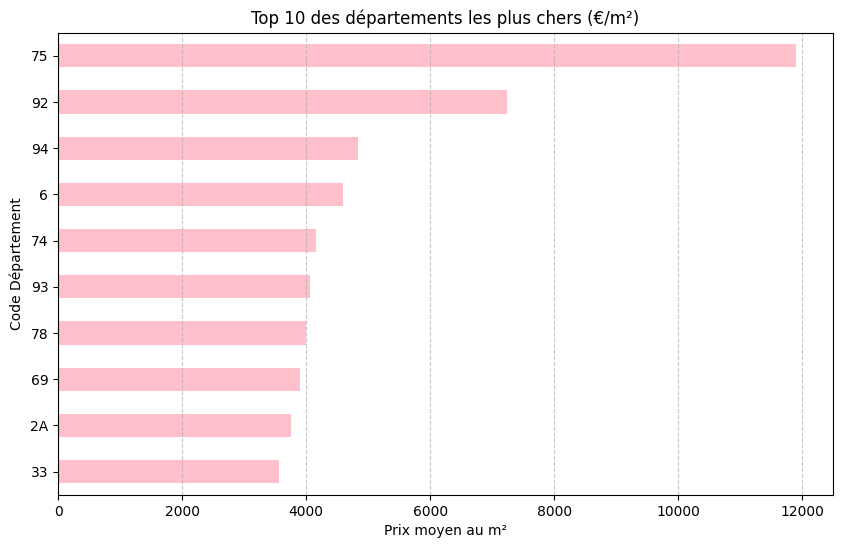

In [42]:
plt.figure(figsize=(10,6))
requete_3.sort_values().plot(kind='barh', color='pink')
plt.title('Top 10 des départements les plus chers (€/m²)')
plt.xlabel('Prix moyen au m²')
plt.ylabel('Code Département')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

ce graphique montre les zones d'investissement prioritaires.

/tmp/ipykernel_395/481998936.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=ventes_trimestre.index, y=ventes_trimestre.values, palette='viridis')


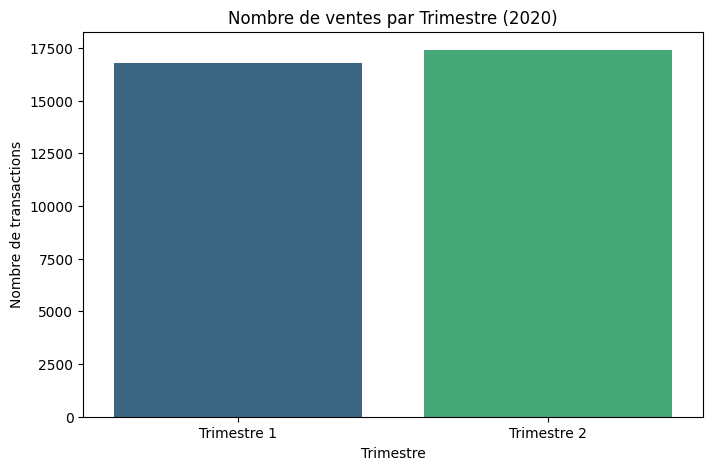

In [43]:
ventes_trimestre = df_final['date_vente'].dt.quarter.value_counts().sort_index()
plt.figure(figsize=(8,5))
sns.barplot(x=ventes_trimestre.index, y=ventes_trimestre.values, palette='viridis')
plt.title('Nombre de ventes par Trimestre (2020)')
plt.xlabel('Trimestre')
plt.ylabel('Nombre de transactions')
plt.xticks([0, 1], ['Trimestre 1', 'Trimestre 2'])
plt.show()

ce graphique nous montre la saisonnalité du marché.

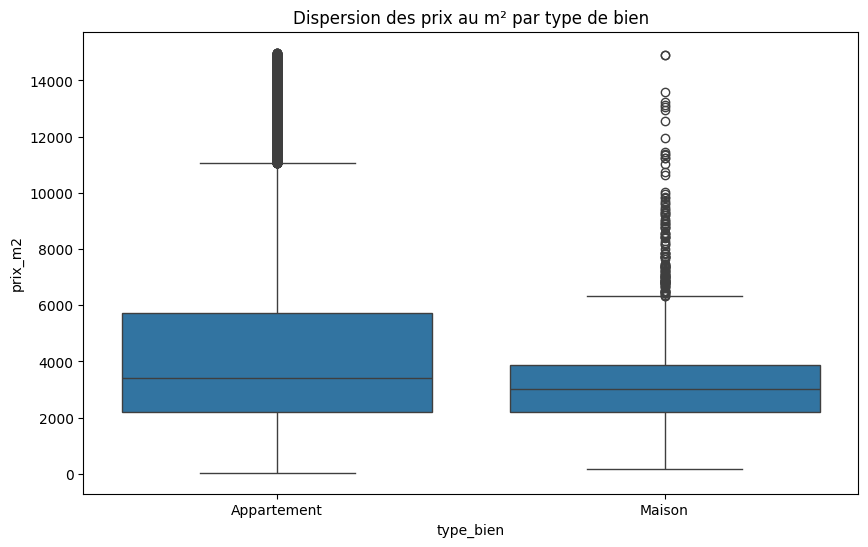

In [44]:
plt.figure(figsize=(10,6))
sns.boxplot(x='type_bien', y='prix_m2', data=df_final[df_final['prix_m2'] < 15000])
plt.title('Dispersion des prix au m² par type de bien')
plt.show()

Repérer les écarts de prix et les valeurs atypiques